In [2]:
!pip -q install qiskit matplotlib pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 107.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.2 MB/s eta 0:00:00


In [3]:
import numpy as np
import matplotlib.pyplot as plt

from math import cos, sin

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import (
    plot_bloch_multivector,
    plot_state_qsphere
)

Statevector:
Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


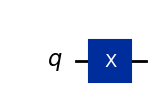

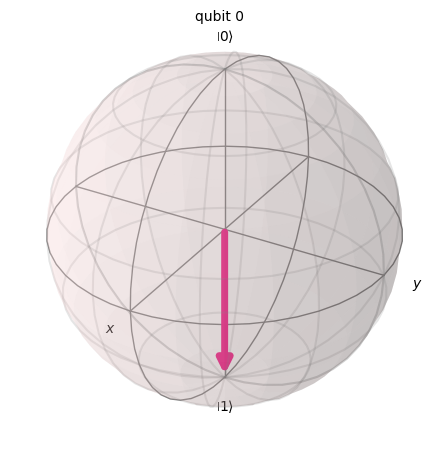

In [4]:
qc = QuantumCircuit(1)

# Apply X gate
qc.x(0)

# Get Statevector
state = Statevector.from_instruction(qc)

print("Statevector:")
print(state)

# Draw Circuit
display(qc.draw("mpl"))

# Bloch Sphere
display(plot_bloch_multivector(state))

Statevector:
Statevector([0.70710678+0.j        , 0.        +0.70710678j],
            dims=(2,))


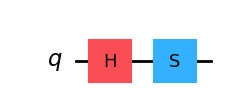

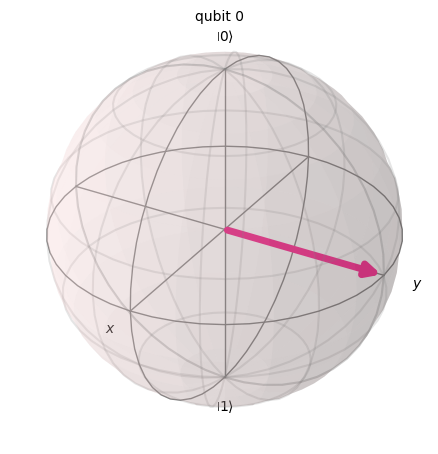

In [5]:
qc = QuantumCircuit(1)

qc.h(0)
qc.s(0)

state = Statevector.from_instruction(qc)

print("Statevector:")
print(state)

display(qc.draw("mpl"))

display(plot_bloch_multivector(state))

Statevector:
Statevector([0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j],
            dims=(2, 2))


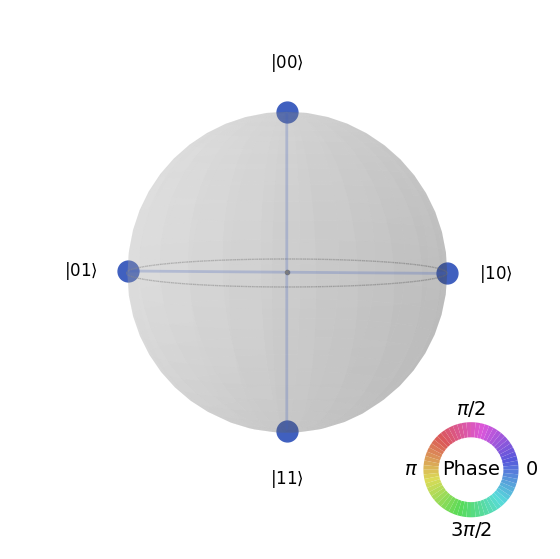


Probabilities:
[0.25 0.25 0.25 0.25]

Sum = 0.9999999999999996


In [6]:
qc = QuantumCircuit(2)

qc.h(0)
qc.h(1)

state = Statevector.from_instruction(qc)

print("Statevector:")
print(state)

display(plot_state_qsphere(state))

# Probability calculation
probabilities = np.abs(state.data)**2

print("\nProbabilities:")
print(probabilities)

print("\nSum =", np.sum(probabilities))

Original State


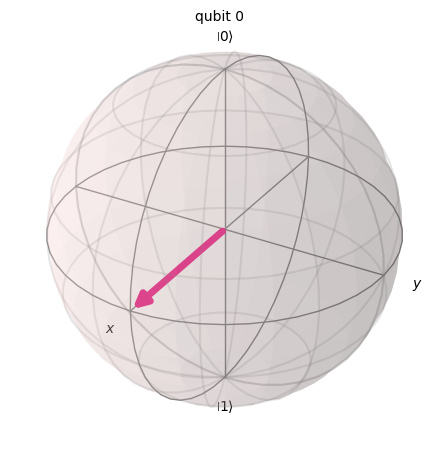

Noisy State


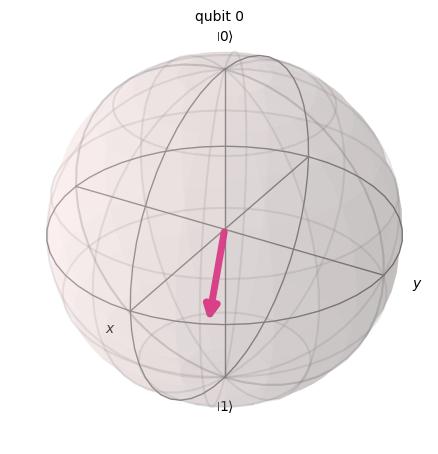

Random Phase = 0.43641872534393755


In [7]:
qc = QuantumCircuit(1)

qc.h(0)

# Original State
original = Statevector.from_instruction(qc)

print("Original State")
display(plot_bloch_multivector(original))

# Random Phase Noise
theta = np.random.uniform(0, 0.5)

qc.p(theta, 0)

noisy = Statevector.from_instruction(qc)

print("Noisy State")
display(plot_bloch_multivector(noisy))

print("Random Phase =", theta)

Statevector:
Statevector([0.70710678+0.j        , 0.35355339+0.61237244j],
            dims=(2,))


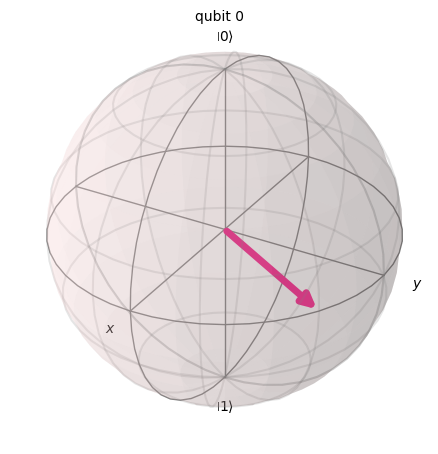

In [8]:
def create_qubit(theta, phi):

    state = np.array([
        cos(theta/2),
        np.exp(1j * phi) * sin(theta/2)
    ])

    return Statevector(state)


theta = np.pi/2
phi = np.pi/3

state = create_qubit(theta, phi)

print("Statevector:")
print(state)

display(plot_bloch_multivector(state))